# TEST VNCORENLP

VnCoreNLP: Bộ công cụ xử lý ngôn ngữ tự nhiên cho tiếng Việt

VnCoreNLP là một bộ công cụ xử lý ngôn ngữ tự nhiên (NLP) nhanh và chính xác dành cho tiếng Việt, cung cấp các chú thích ngôn ngữ phong phú thông qua các thành phần NLP chính như phân đoạn từ, gán nhãn từ loại (POS tagging), nhận diện thực thể có tên (NER) và phân tích cú pháp phụ thuộc. Người dùng không cần cài đặt các thư viện phụ thuộc bên ngoài. Họ có thể chạy các quy trình xử lý thông qua dòng lệnh hoặc API.

https://github.com/vncorenlp/VnCoreNLP

In [1]:
import py_vncorenlp
import os

# Tự động tải model về thư mục "/content/vncorenlp"
# Ensure the parent directory exists before creating subdirectories
save_dir = "/content/vncorenlp"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)  # Create the parent directory if it doesn't exist

py_vncorenlp.download_model(save_dir=save_dir)

VnCoreNLP model folder /content/vncorenlp already exists! Please load VnCoreNLP from this folder!


In [2]:
# Load bộ tách từ (word segmentation)
rdrsegmenter = py_vncorenlp.VnCoreNLP(annotators=["wseg"], save_dir="/content/vncorenlp")

# Test tách từ
text = "Ông Nguyễn Khắc Chúc đang làm việc tại Đại học Quốc gia Hà Nội."
output = rdrsegmenter.word_segment(text)

print(output)
# Kết quả mong đợi: ['Ông Nguyễn_Khắc_Chúc đang làm_việc tại Đại_học Quốc_gia Hà_Nội .']


['Ông Nguyễn_Khắc_Chúc đang làm_việc tại Đại_học Quốc_gia Hà_Nội .']


#Dataset

#**Bộ Dữ Liệu Phản Hồi Sinh Viên Tiếng Việt Tổng Hợp**

Về Bộ Dữ Liệu

Bộ dữ liệu Synthetic Vietnamese Students’ Feedback Corpus là một tập dữ liệu tổng hợp dựa trên hướng dẫn của UIT-VSFC Vietnamese Students Feedback Corpus, được thiết kế đặc biệt cho phân tích cảm xúc. Bộ dữ liệu này bao gồm hơn 10.000 câu, mỗi câu được gán nhãn với một trong ba cảm xúc: tích cực, tiêu cực hoặc trung lập. Ngoài ra, mỗi câu còn được phân loại vào một trong bốn chủ đề: giảng viên, chương trình học, cơ sở vật chất và các chủ đề khác.

Điểm đặc biệt của tập dữ liệu này là nó được tổng hợp bằng ChatGPT API, thay vì thu thập từ phản hồi thực tế của sinh viên. Điều này giúp kiểm soát tốt hơn quá trình tạo dữ liệu, đồng thời cho phép tạo ra một lượng lớn dữ liệu một cách nhanh chóng và hiệu quả.

Bộ dữ liệu này được sử dụng để huấn luyện và đánh giá các mô hình phân tích cảm xúc, đặc biệt là các mô hình phân tích phản hồi trong ngành nhà hàng tại Việt Nam. Với sự đa dạng về cảm xúc và chủ đề, Synthetic Vietnamese Students’ Feedback Corpus là một nguồn tài nguyên giá trị dành cho các nhà nghiên cứu và nhà phát triển đang tìm cách cải thiện độ chính xác và hiệu quả của phân tích cảm xúc trong tiếng Việt.

Link: https://www.kaggle.com/datasets/toreleon/synthetic-vietnamese-students-feedback-corpus/data

#1️⃣ Mount Google Drive vào Colab

In [3]:
from google.colab import drive
drive.mount('/content/drive')  # Kết nối Google Drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#2️⃣ Đọc file CSV từ Drive


In [4]:
from google.colab import files
import pandas as pd

# Upload file thủ công từ máy tính
uploaded = files.upload()


Saving synthetic_train.csv to synthetic_train (2).csv


In [5]:
# Upload file thủ công từ máy tính
uploaded = files.upload()


Saving synthetic_val.csv to synthetic_val (2).csv


In [6]:
# Đọc file đã upload (giả sử tên file là đúng)
df_train = pd.read_csv("synthetic_train.csv")
df_val = pd.read_csv("synthetic_val.csv")

# Hiển thị 5 dòng đầu tiên
print(df_train.head())
print(df_val.head())

                                            sentence sentiment       topic
0  Đội ngũ bảo trì quá thưa thớt dẫn đến không đả...  negative    facility
1  The university's musical and artistic faciliti...   neutral    facility
2  Phương pháp giảng dạy phù hợp với các đối tượn...   neutral  curriculum
3  Chương trình học giúp tôi trở thành một chuyên...  positive  curriculum
4  Tôi nghĩ rằng chương trình đào tạo có thể có t...   neutral  curriculum
                                            sentence sentiment       topic
0                           Chất lượng vật chất kém.  negative    facility
1  Phần mềm học tập quá khó sử dụng, khiến sinh v...  negative    facility
2  Trường tôi thiếu những tiện ích cơ bản như máy...  negative    facility
3  Cần tạo thêm các hoạt động gắn kết giữa sinh v...   neutral  curriculum
4  Họ rất khoan dung và lượng giác trong quan điể...   neutral      others


In [7]:
print(df_train.columns)


Index(['sentence', 'sentiment', 'topic'], dtype='object')


#Tách thử một đoạn

In [8]:
import py_vncorenlp

def process_text(text):
    # Initialize VnCoreNLP only if it hasn't been initialized before
    if 'rdrsegmenter' not in globals():
        global rdrsegmenter  # Declare rdrsegmenter as global
        rdrsegmenter = py_vncorenlp.VnCoreNLP(annotators=["wseg"], save_dir="/content/vncorenlp")

    # Use the existing rdrsegmenter object if it's already initialized
    return " ".join(rdrsegmenter.word_segment(text))

# Tách từ từng câu trong cột "sentence"
df_train["tokenized_sentence"] = df_train["sentence"].apply(process_text)

# Xem kết quả
print(df_train.head())

                                            sentence sentiment       topic  \
0  Đội ngũ bảo trì quá thưa thớt dẫn đến không đả...  negative    facility   
1  The university's musical and artistic faciliti...   neutral    facility   
2  Phương pháp giảng dạy phù hợp với các đối tượn...   neutral  curriculum   
3  Chương trình học giúp tôi trở thành một chuyên...  positive  curriculum   
4  Tôi nghĩ rằng chương trình đào tạo có thể có t...   neutral  curriculum   

                                  tokenized_sentence  
0  Đội_ngũ bảo_trì quá thưa_thớt dẫn đến không đả...  
1  The university ' s musical and artistic facili...  
2  Phương_pháp giảng_dạy phù_hợp với các đối_tượn...  
3  Chương_trình học giúp tôi trở_thành một chuyên...  
4  Tôi nghĩ rằng chương_trình đào_tạo có_thể có t...  


#LDA

In [9]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

# Chuyển dữ liệu text thành ma trận BoW
vectorizer = CountVectorizer()
data_vectorized = vectorizer.fit_transform(df_train["sentence"])

# Chạy LDA với sklearn
lda_model = LatentDirichletAllocation(n_components=5, random_state=42)
lda_model.fit(data_vectorized)

print("LDA chạy xong!")


LDA chạy xong!


In [10]:
# Số chủ đề (n_components) bạn đã chọn khi chạy LDA
num_topics = 5

# Lấy danh sách từ vựng
words = vectorizer.get_feature_names_out()

# In ra mỗi chủ đề với các từ quan trọng nhất
for topic_idx, topic in enumerate(lda_model.components_):
    print(f"\n🔹 Chủ đề {topic_idx+1}:")
    print(" ".join([words[i] for i in topic.argsort()[:-11:-1]]))  # Lấy 10 từ quan trọng nhất



🔹 Chủ đề 1:
viên giảng và sinh rất học dạy thầy này của

🔹 Chủ đề 2:
trường và viên sinh không học của cho tập chất

🔹 Chủ đề 3:
học và các viên sinh trình được có trường tập

🔹 Chủ đề 4:
và người tôi không của luôn rất bạn khác ấy

🔹 Chủ đề 5:
và là the người rất ấy việc có một anh


##  Lấy 10 từ có xác suất cao nhất cho mỗi chủ đề

In [11]:
# Chọn chủ đề đầu tiên (chỉ số 0)
first_topic = lda_model.components_[0]

# Lấy chỉ số của 10 từ có xác suất cao nhất trong chủ đề này
top_word_indices = first_topic.argsort()[-10:]

# In ra 10 từ đó
print("🔹 10 từ quan trọng nhất của chủ đề đầu tiên:")
for idx in top_word_indices:
    print(words[idx])


🔹 10 từ quan trọng nhất của chủ đề đầu tiên:
của
này
thầy
dạy
học
rất
sinh
và
giảng
viên


##  In 10 từ quan trọng nhất cho tất cả các chủ đề

In [12]:
# In ra 10 từ có xác suất cao nhất cho mỗi chủ đề
for topic_idx, topic in enumerate(lda_model.components_):
    print(f"\n🔹 Chủ đề {topic_idx + 1}:")
    top_word_indices = topic.argsort()[-10:]
    print(" ".join([words[i] for i in top_word_indices]))



🔹 Chủ đề 1:
của này thầy dạy học rất sinh và giảng viên

🔹 Chủ đề 2:
chất tập cho của học không sinh viên và trường

🔹 Chủ đề 3:
tập trường có được trình sinh viên các và học

🔹 Chủ đề 4:
ấy khác bạn rất luôn của không tôi người và

🔹 Chủ đề 5:
anh một có việc ấy rất người the là và


## Tính phân phối xác suất mỗi văn bản thuộc về các chủ đề

In [13]:
# Biến đổi dữ liệu văn bản thành phân phối xác suất theo từng chủ đề
topic_distributions = lda_model.transform(data_vectorized)

# Kiểm tra kích thước: số dòng = số văn bản, số cột = số chủ đề
print("Kích thước ma trận phân phối chủ đề:", topic_distributions.shape)


Kích thước ma trận phân phối chủ đề: (8144, 5)


## Gán chủ đề chính cho từng văn bản

In [14]:
# Gán chủ đề có xác suất cao nhất cho mỗi văn bản
main_topics = topic_distributions.argmax(axis=1)

# Tạo cột mới trong DataFrame để lưu chủ đề
df_train["main_topic"] = main_topics

# In thử vài dòng đầu
print(df_train[["sentence", "main_topic"]].head())


                                            sentence  main_topic
0  Đội ngũ bảo trì quá thưa thớt dẫn đến không đả...           1
1  The university's musical and artistic faciliti...           4
2  Phương pháp giảng dạy phù hợp với các đối tượn...           0
3  Chương trình học giúp tôi trở thành một chuyên...           2
4  Tôi nghĩ rằng chương trình đào tạo có thể có t...           2


##WORD CLOUD

<ipython-input-15-f6928e877129>:20: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


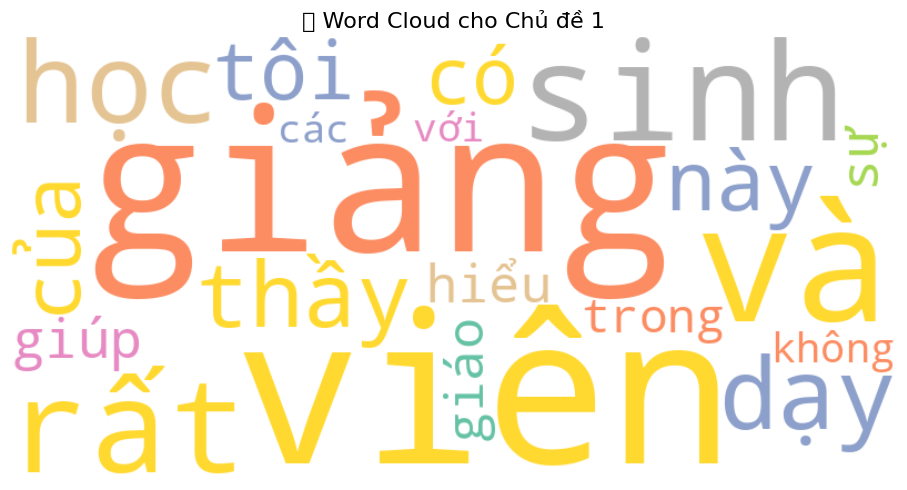

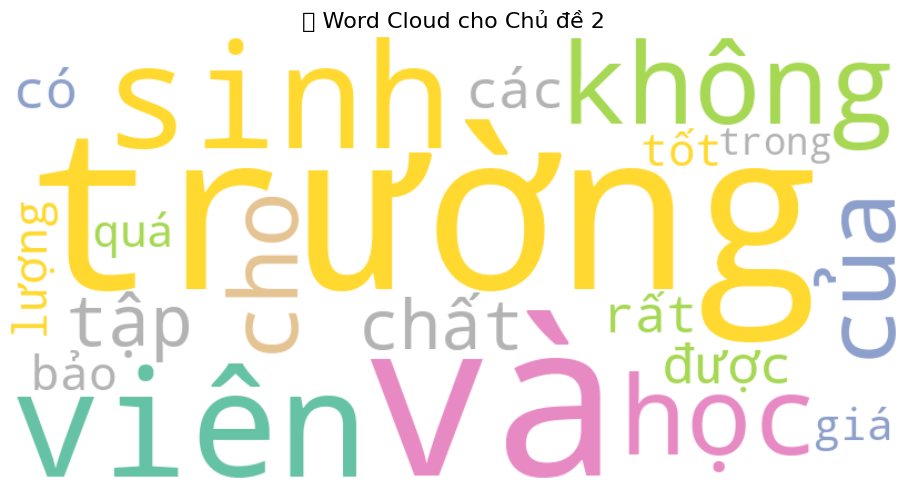

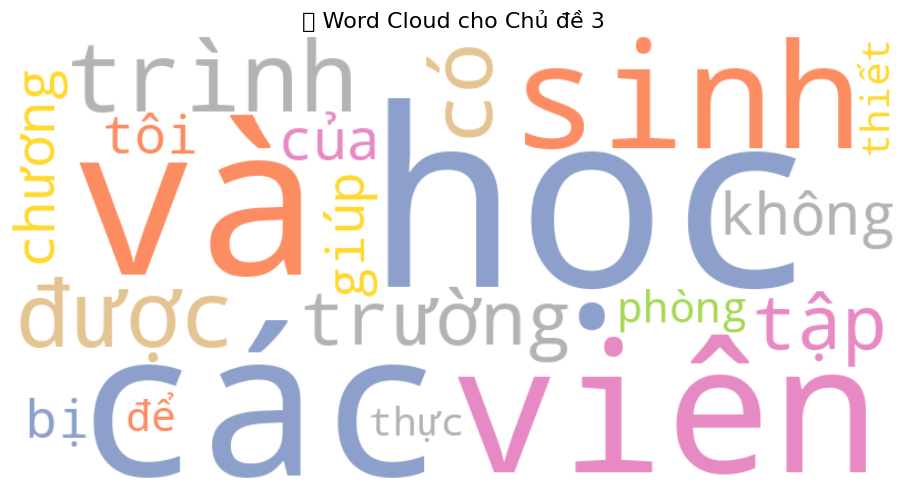

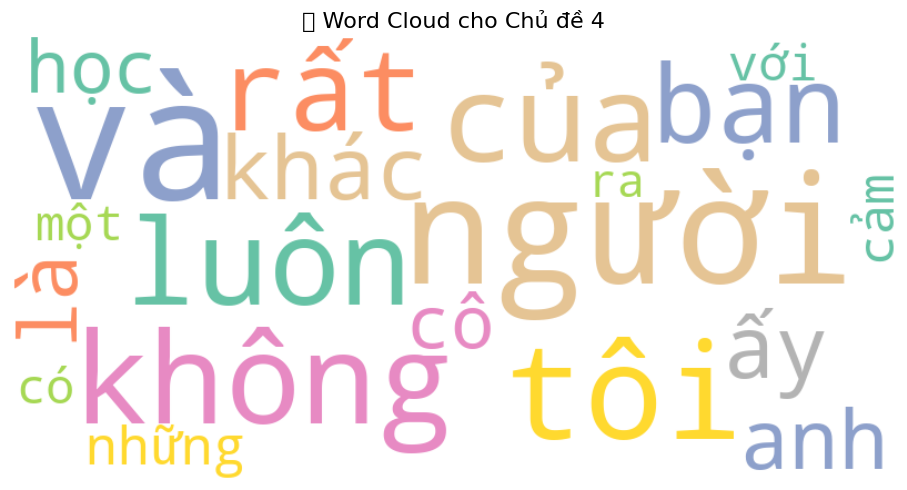

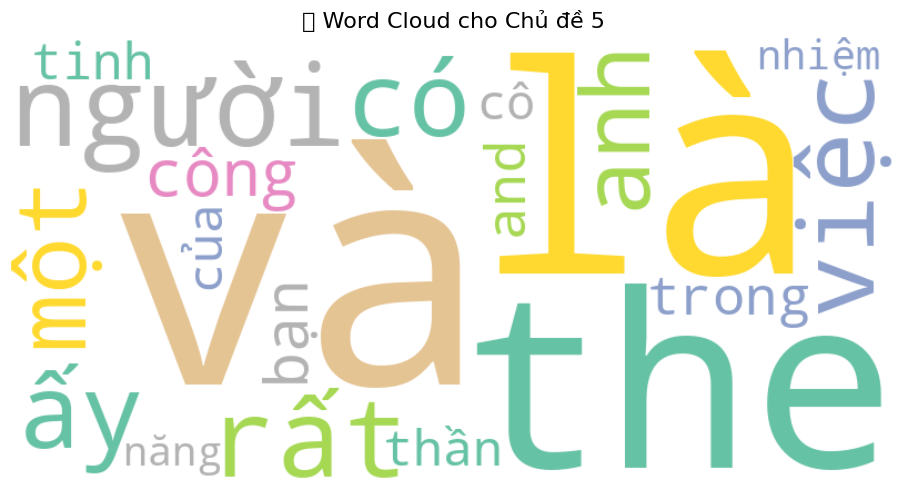

In [15]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def draw_wordclouds_per_topic(lda_model, vectorizer, num_words=20):
    feature_names = vectorizer.get_feature_names_out()

    for topic_idx, topic in enumerate(lda_model.components_):
        # Lấy từ và trọng số
        topic_words = {feature_names[i]: topic[i] for i in topic.argsort()[-num_words:]}

        # Tạo WordCloud
        wc = WordCloud(width=800, height=400, background_color='white', colormap='Set2')
        wc.generate_from_frequencies(topic_words)

        # Hiển thị
        plt.figure(figsize=(10, 5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis("off")
        plt.title(f'🔹 Word Cloud cho Chủ đề {topic_idx + 1}', fontsize=16)
        plt.tight_layout()
        plt.show()

# Gọi hàm để vẽ Word Cloud cho từng chủ đề, sử dụng 'vectorizer' thay vì 'count_vectorizer'
draw_wordclouds_per_topic(lda_model, vectorizer)

##Vector hóa văn bản (Bag-of-Words)

In [16]:
# ===== Bước 5: Vector hóa văn bản (Bag-of-Words) =====
# Assuming 'df_train' contains your data with a 'tokenized_sentence' column
vectorizer = CountVectorizer(stop_words='english', max_df=0.9, min_df=2)
X = vectorizer.fit_transform(df_train['tokenized_sentence']) # Changed 'papers' to 'df_train' and 'paper_text_processed' to 'tokenized_sentence'

## Vẽ biểu đồ 10 từ phổ biến nhất

<ipython-input-17-d0702b32b27a>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_counts[sorted_idx], y=[word_names[i] for i in sorted_idx], palette='viridis') # Now 'sns' is defined and can be used
<ipython-input-17-d0702b32b27a>:15: UserWarning: Glyph 128288 (\N{INPUT SYMBOL FOR LATIN CAPITAL LETTERS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128288 (\N{INPUT SYMBOL FOR LATIN CAPITAL LETTERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


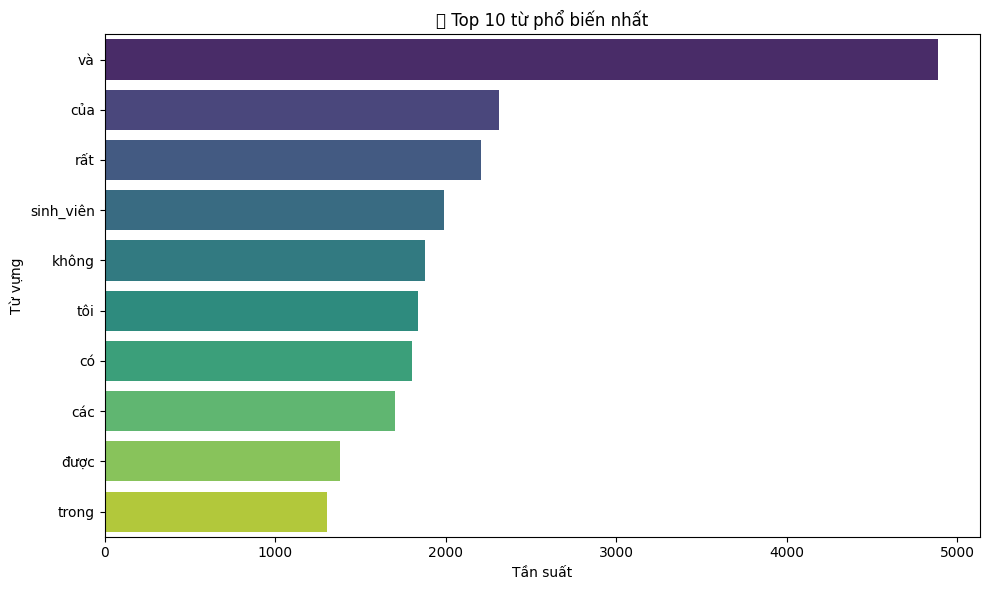

In [17]:
import seaborn as sns  # Import seaborn and alias it as 'sns'
import numpy as np
import matplotlib.pyplot as plt

def plot_top_words(X, vectorizer, n=10):
    word_names = vectorizer.get_feature_names_out()
    word_counts = np.asarray(X.sum(axis=0)).flatten()
    sorted_idx = np.argsort(word_counts)[::-1][:n]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=word_counts[sorted_idx], y=[word_names[i] for i in sorted_idx], palette='viridis') # Now 'sns' is defined and can be used
    plt.title(f'🔠 Top {n} từ phổ biến nhất')
    plt.xlabel('Tần suất')
    plt.ylabel('Từ vựng')
    plt.tight_layout()
    plt.show()

plot_top_words(X, vectorizer)

##  Huấn luyện mô hình LDA

In [18]:
lda_model = LatentDirichletAllocation(n_components=5, random_state=42)
lda_model.fit(X)

LatentDirichletAllocation(n_components=5, random_state=42)

## In các chủ đề và từ khóa đại diện

In [19]:
def print_lda_topics(model, vectorizer, n_top_words=10):
    words = vectorizer.get_feature_names_out()
    for topic_idx, topic in enumerate(model.components_):
        print(f"\n🔸 Chủ đề {topic_idx + 1}:")
        print(" | ".join([words[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

print_lda_topics(lda_model, vectorizer)


🔸 Chủ đề 1:
và | giảng_viên | thầy | rất | giúp | ra | sinh_viên | tôi | kiến_thức | hiểu

🔸 Chủ đề 2:
không | sinh_viên | của | và | sự | quá | học | có | chương_trình | với

🔸 Chủ đề 3:
tôi | và | rất | của | trường | được | này | cảm_thấy | học | giảng_viên

🔸 Chủ đề 4:
và | người | rất | là | ấy | có | bạn | anh | luôn | của

🔸 Chủ đề 5:
các | và | sinh_viên | trường | cho | được | phòng | giúp | học_tập | có


##PhoBERT

In [20]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
from tqdm import tqdm

# Load PhoBERT
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
model = AutoModel.from_pretrained("vinai/phobert-base")
model.eval()

# Hàm mã hóa một câu đã được tách từ
def encode_phobert(text):
    input_ids = tokenizer.encode(text, return_tensors="pt", truncation=True, max_length=256)
    with torch.no_grad():
        last_hidden_state = model(input_ids)[0]
        sentence_embedding = torch.mean(last_hidden_state, dim=1).squeeze().numpy()
    return sentence_embedding

# Encode tất cả câu đã tách từ
embeddings = np.array([encode_phobert(sent) for sent in tqdm(df_train["tokenized_sentence"])])


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
100%|██████████| 8144/8144 [18:21<00:00,  7.39it/s]


In [21]:
import umap
import matplotlib.pyplot as plt

# Giảm chiều
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embedding_2d = reducer.fit_transform(embeddings)




/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


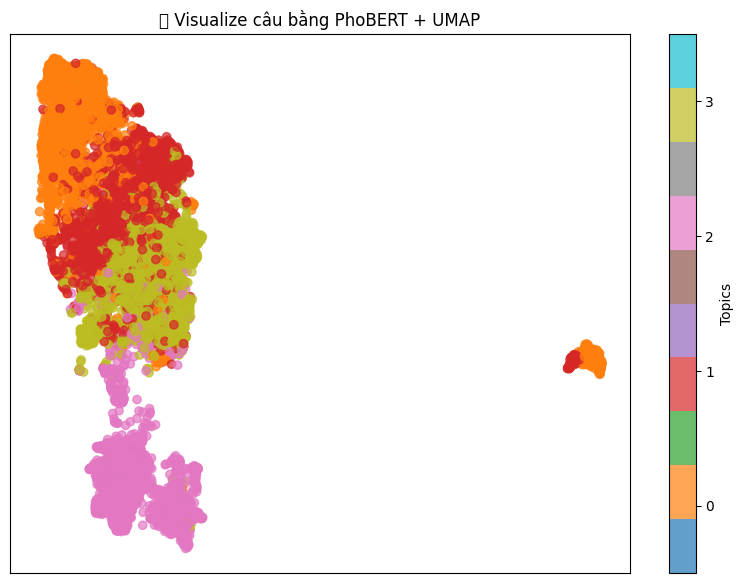

In [22]:
# Vẽ biểu đồ, mỗi điểm là 1 câu, tô màu theo chủ đề hoặc cảm xúc nếu muốn
plt.figure(figsize=(10, 7))
topics = df_train['topic']
unique_topics = topics.unique()
colors = {topic: i for i, topic in enumerate(unique_topics)}
color_vals = [colors[t] for t in topics]

scatter = plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], c=color_vals, cmap="tab10", alpha=0.7)
plt.title("🌐 Visualize câu bằng PhoBERT + UMAP")
plt.colorbar(scatter, ticks=range(len(unique_topics)), label='Topics')
plt.clim(-0.5, len(unique_topics)-0.5)
plt.xticks([]); plt.yticks([])
plt.show()

## Vector hóa văn bản bằng Bag-of-Words

In [23]:
count_vectorizer = CountVectorizer(stop_words='english')
count_data = count_vectorizer.fit_transform(df_train['tokenized_sentence'])

<ipython-input-24-35a727723e53>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_counts[sorted_idx], y=[word_names[i] for i in sorted_idx], palette='viridis')
<ipython-input-24-35a727723e53>:11: UserWarning: Glyph 128288 (\N{INPUT SYMBOL FOR LATIN CAPITAL LETTERS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128288 (\N{INPUT SYMBOL FOR LATIN CAPITAL LETTERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


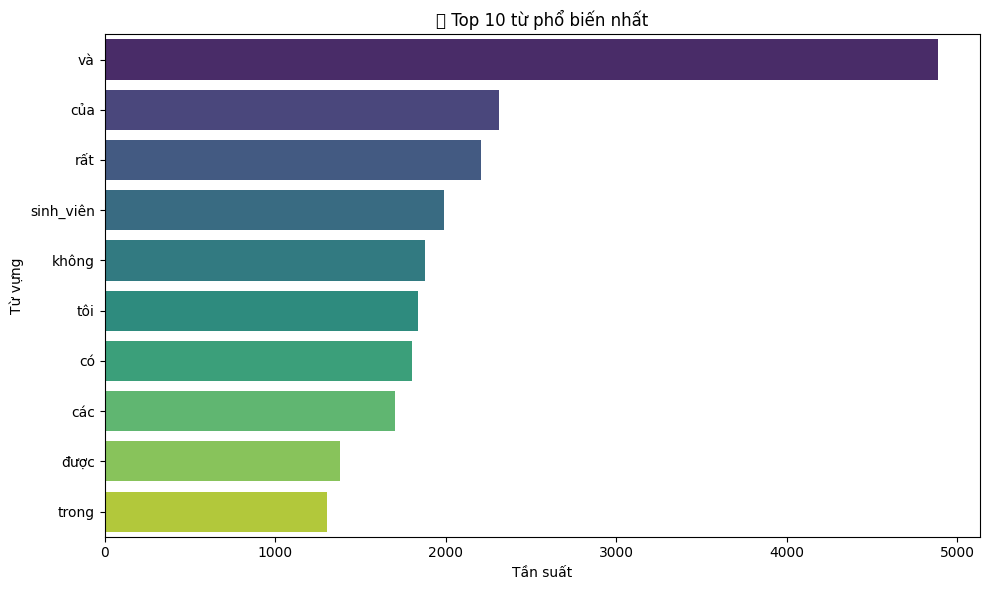

In [24]:
def plot_top_words(X, vectorizer, n=10):
    word_names = vectorizer.get_feature_names_out()
    word_counts = np.asarray(X.sum(axis=0)).flatten()
    sorted_idx = np.argsort(word_counts)[::-1][:n]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=word_counts[sorted_idx], y=[word_names[i] for i in sorted_idx], palette='viridis')
    plt.title(f'🔠 Top {n} từ phổ biến nhất')
    plt.xlabel('Tần suất')
    plt.ylabel('Từ vựng')
    plt.tight_layout()
    plt.show()

plot_top_words(count_data, count_vectorizer)

## Hàm tìm số cụm tối ưu bằng phương pháp Elbow Method

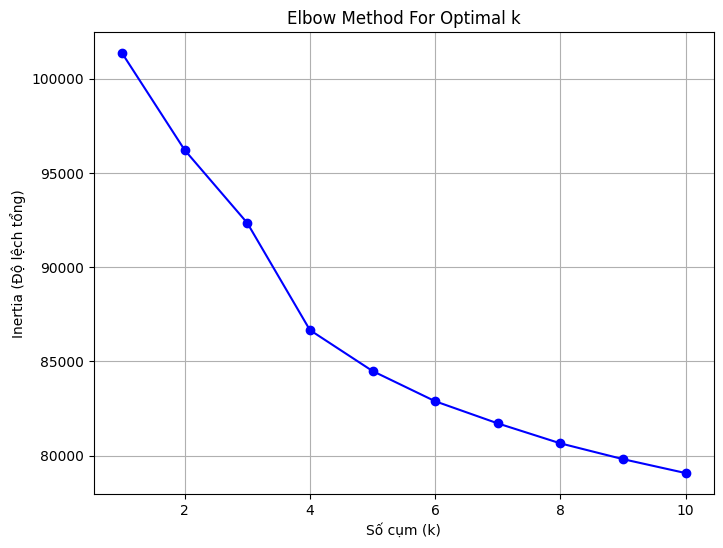

In [25]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def elbow_method(embeddings, max_clusters=10):
    inertia = []
    for n_clusters in range(1, max_clusters + 1):
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        kmeans.fit(embeddings)
        inertia.append(kmeans.inertia_)

    # Vẽ đồ thị Elbow Method
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, max_clusters + 1), inertia, marker='o', color='b')
    plt.title('Elbow Method For Optimal k')
    plt.xlabel('Số cụm (k)')
    plt.ylabel('Inertia (Độ lệch tổng)')
    plt.grid(True)
    plt.show()

# Áp dụng Elbow Method để tìm số cụm tối ưu
elbow_method(embeddings, max_clusters=10)

## Huấn luyện mô hình PhoBERT và phân nhóm chủ đề bằng KMeans

In [26]:

num_clusters = int(input("Nhập số cụm bạn muốn: "))

# Huấn luyện mô hình KMeans với số cụm đã nhập
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(embeddings)


print(f"Cluster centers for {num_clusters} clusters:")
print(kmeans.cluster_centers_)


Nhập số cụm bạn muốn: 4
Cluster centers for 4 clusters:
[[ 0.00962314  0.01006281 -0.1008262  ...  0.06130857 -0.21916033
   0.12427324]
 [-0.02240814  0.11116922 -0.09610532 ...  0.02829531 -0.21067755
   0.12857082]
 [-0.013861    0.07235943 -0.07466529 ...  0.09075032 -0.20134486
   0.01337927]
 [ 0.01857244 -0.03422679 -0.3583895  ... -0.175723   -0.08596139
   0.06648326]]


##  Lấy 10 từ có xác suất cao nhất cho mỗi chủ đề

In [27]:
def print_top_words_for_topics(count_vectorizer, kmeans, n_top_words=10):
    words = count_vectorizer.get_feature_names_out()
    for topic_idx, topic in enumerate(kmeans.cluster_centers_):
        print(f"\n🔹 Chủ đề {topic_idx + 1}:")
        topic_words = [words[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(" ".join(topic_words))

print_top_words_for_topics(count_vectorizer, kmeans)


🔹 Chủ đề 1:
cậu chuyên_cần bathrooms current anh căn_cứ_quân_sự dẫn dùng atms anh_chàng

🔹 Chủ đề 2:
cậu chuyên_cần căn_cứ_quân_sự bathrooms bản_chất current dùng campus employment dẫn

🔹 Chủ đề 3:
cậu chuyên_cần bathrooms căn_cứ_quân_sự atms cơm current core dùng dẫn

🔹 Chủ đề 4:
cậu chuyên_cần chỉ_dẫn bạn_bè bất_an difficulty commute can_đảm châm_chọc cập_nhật_kiến


## Tính phân phối xác suất mỗi văn bản thuộc về các chủ đề

In [28]:
topic_distribution = kmeans.transform(embeddings)
df_train['topic_probabilities'] = list(topic_distribution)


##  Gán chủ đề chính cho từng văn bản

In [29]:
df_train['main_topic'] = df_train['topic_probabilities'].apply(lambda x: np.argmax(x))

##  Word Cloud

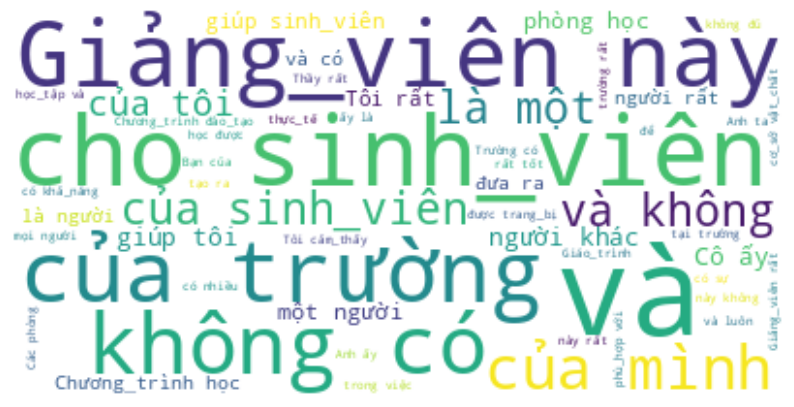

In [30]:
def generate_word_cloud(text_data):
    long_string = ','.join(list(text_data.values))
    wordcloud = WordCloud(background_color="white", max_words=5000, contour_width=3, contour_color='steelblue')
    wordcloud.generate(long_string)
    plt.figure(figsize=(10, 10))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

generate_word_cloud(df_train['tokenized_sentence'])

## In các chủ đề và từ khóa đại diện

In [31]:
def print_topics_from_kmeans(kmeans, df_train, n_top_words=10):
    for topic_num in range(num_clusters):
        print(f"\n🔸 Chủ đề {topic_num + 1}:")
        topic_sentences = df_train[df_train['main_topic'] == topic_num]['tokenized_sentence'].head(5)
        print("Các câu đại diện:")
        print("\n".join(topic_sentences.values))

print_topics_from_kmeans(kmeans, df_train)


🔸 Chủ đề 1:
Các câu đại diện:
The campus has a community garden .
I like how the curriculum prioritizes practical skills and real-world applications .
The curriculum is relevant to current industry trends .
The campus has a sustainable living program .
Overall , I feel that the curriculum adequately prepares students for their future careers .

🔸 Chủ đề 2:
Các câu đại diện:
The university ' s musical and artistic facilities are excellent .
The university provides a comfortable and conducive environment for learning .
I appreciate the opportunities provided by the curriculum to interact with industry professionals .
The university provides legal advice for students .
The university has a good range of research facilities .

🔸 Chủ đề 3:
Các câu đại diện:


🔸 Chủ đề 4:
Các câu đại diện:
Đội_ngũ bảo_trì quá thưa_thớt dẫn đến không đảm_bảo được chất_lượng sửa_chữa thiết_bị .
Phương_pháp giảng_dạy phù_hợp với các đối_tượng sinh_viên khác nhau .
Chương_trình học giúp tôi trở_thành một chuyên